In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import scipy.stats as ss
from sklearn.preprocessing import MinMaxScaler
import scipy.fft
from scipy.signal.windows import hann
from scipy.signal import welch
from scipy.signal import savgol_filter

In [2]:
# Working on updates here so original notebook file doesn't get to large
# Load data from before:
column_names = ['NS', 'EW', 'Z', 'nsL', 'ewL', 'zL', 'aY', 'aX', 'aZ']
df = pd.read_table('hwy15_2025_001.asc', delimiter=r'\s+', encoding='latin-1', skiprows=32, names=column_names)

column_names2 = ['NS', 'EW', 'Z', 'nsL', 'ewL', 'zL', 'aY', 'aX', 'aZ']
df2 = pd.read_table('hwy15_2025_2_001.asc', delimiter=r'\s+', encoding='latin-1', skiprows=32, names=column_names2)

column_names3 = ['NS', 'EW', 'Z', 'nsL', 'ewL', 'zL', 'aY', 'aX', 'aZ']
df3 = pd.read_table('hwy15_2025_3_001.asc', delimiter=r'\s+', encoding='latin-1', skiprows=32, names=column_names3)

# Want to make a time column:
original_sampling_rate = 1024  # Hz (same for all data files)
dataframes = [df, df2, df3]
for i, dataframe in enumerate(dataframes):
    time = dataframe.index/original_sampling_rate
    dataframe['time (s)'] = time
    print(dataframe.head())

      NS     EW      Z   nsL  ewL    zL     aY     aX    aZ  time (s)
0  208.0  116.0  658.0   6.0  3.0  20.0  150.0  313.0  29.0  0.000000
1  268.0  155.0  690.0   8.0  4.0  21.0  147.0  315.0  34.0  0.000977
2  313.0  190.0  762.0   9.0  5.0  23.0  150.0  312.0  35.0  0.001953
3  346.0  229.0  853.0  10.0  7.0  26.0  144.0  312.0  31.0  0.002930
4  375.0  280.0  927.0  11.0  8.0  28.0  148.0  317.0  33.0  0.003906
      NS     EW      Z  nsL   ewL    zL     aY     aX    aZ  time (s)
0  156.0  324.0  817.0  4.0  10.0  25.0  199.0   97.0  20.0  0.000000
1  160.0  306.0  842.0  5.0   9.0  26.0  196.0  101.0  18.0  0.000977
2  164.0  287.0  869.0  5.0   8.0  27.0  195.0   99.0  20.0  0.001953
3  175.0  272.0  892.0  5.0   8.0  27.0  194.0  100.0  23.0  0.002930
4  184.0  250.0  909.0  5.0   7.0  28.0  198.0  106.0  19.0  0.003906
      NS     EW      Z  nsL  ewL    zL     aY     aX    aZ  time (s)
0  243.0  249.0  818.0  7.0  7.0  25.0  156.0  392.0  25.0  0.000000
1  204.0  244.0  779.0

In [3]:
# Normalize, detrend and shift data:
for i, dframe in enumerate(dataframes):
    if i==0:
        print("dataframe: df")
    else:
        print(f"dataframe: df{i+1}")

    # Linearly detrend data, normalize and shift to zero mean:
    # Detrend
    dframe['NS_Detrended'] = signal.detrend(dframe['NS'], type='linear') # North-South data
    dframe['EW_Detrended'] = signal.detrend(dframe['EW'], type='linear') # East-West data
    dframe['Z_Detrended'] = signal.detrend(dframe['Z'], type='linear') # Z-component data
    
    # Normalize
    scaler = MinMaxScaler()
    dframe['NS_Normalized'] = scaler.fit_transform(dframe['NS_Detrended'].values.reshape(-1, 1)).flatten() # North-South
    dframe['EW_Normalized'] = scaler.fit_transform(dframe['EW_Detrended'].values.reshape(-1, 1)).flatten() # East-West
    dframe['Z_Normalized'] = scaler.fit_transform(dframe['Z_Detrended'].values.reshape(-1, 1)).flatten() # Z-component
    #print(f"NS Min-Max normalized range: [{dframe['NS_Normalized'].min():.3f}, {dframe['NS_Normalized'].max():.3f}]")
    #print(f"EW Min-Max normalized range: [{dframe['EW_Normalized'].min():.3f}, {dframe['EW_Normalized'].max():.3f}]")
    #print(f"Z Min-Max normalized range: [{dframe['Z_Normalized'].min():.3f}, {dframe['Z_Normalized'].max():.3f}]")
    
    # Shift Mean:
    dframe['NS_Normalized_Shifted'] = (dframe['NS_Normalized'] - np.mean(dframe['NS_Normalized']))
    dframe['EW_Normalized_Shifted'] = (dframe['EW_Normalized'] - np.mean(dframe['EW_Normalized']))
    dframe['Z_Normalized_Shifted'] = (dframe['Z_Normalized'] - np.mean(dframe['Z_Normalized']))
    #print(f"New range for NS: [{dframe['NS_Normalized_Shifted'].min():.3f}, {dframe['NS_Normalized_Shifted'].max():.3f}]")
    #print(f"New mean for NS: {dframe['NS_Normalized_Shifted'].mean():.6f}")
    #print(f"New range for EW: [{dframe['EW_Normalized_Shifted'].min():.3f}, {dframe['EW_Normalized_Shifted'].max():.3f}]")
    #print(f"New mean for EW: {dframe['EW_Normalized_Shifted'].mean():.6f}")
    #print(f"New range for Z: [{dframe['Z_Normalized_Shifted'].min():.3f}, {dframe['Z_Normalized_Shifted'].max():.3f}]")
    #print(f"New mean for Z: {dframe['Z_Normalized_Shifted'].mean():.6f}")

dataframe: df
dataframe: df2
dataframe: df3


dataframe: df


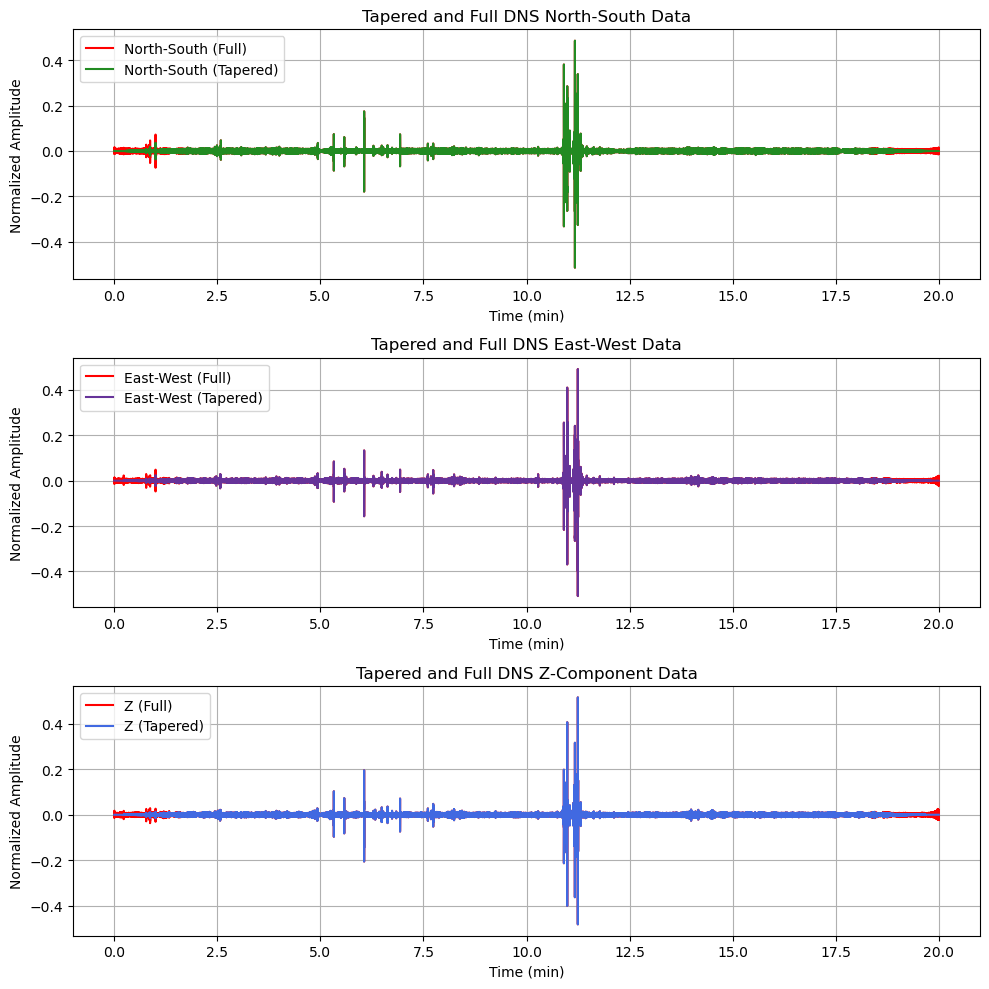

dataframe: df2


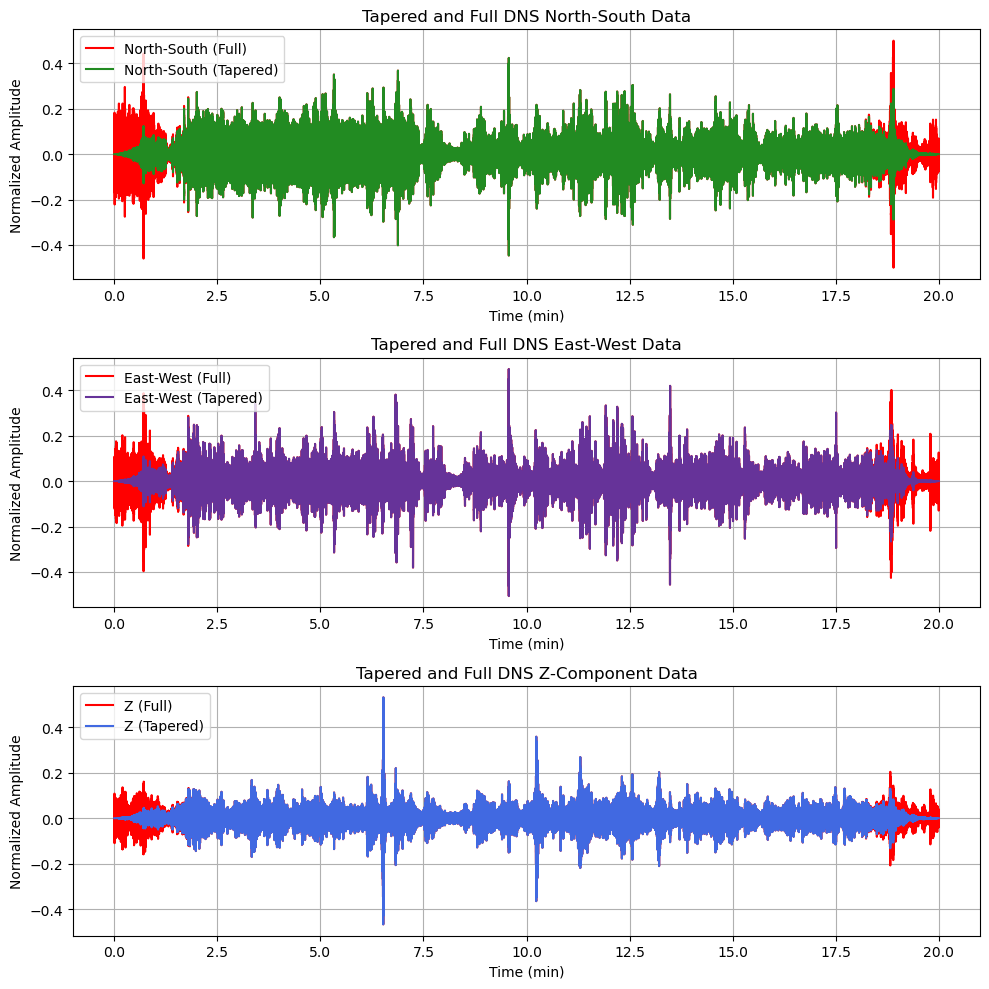

dataframe: df3


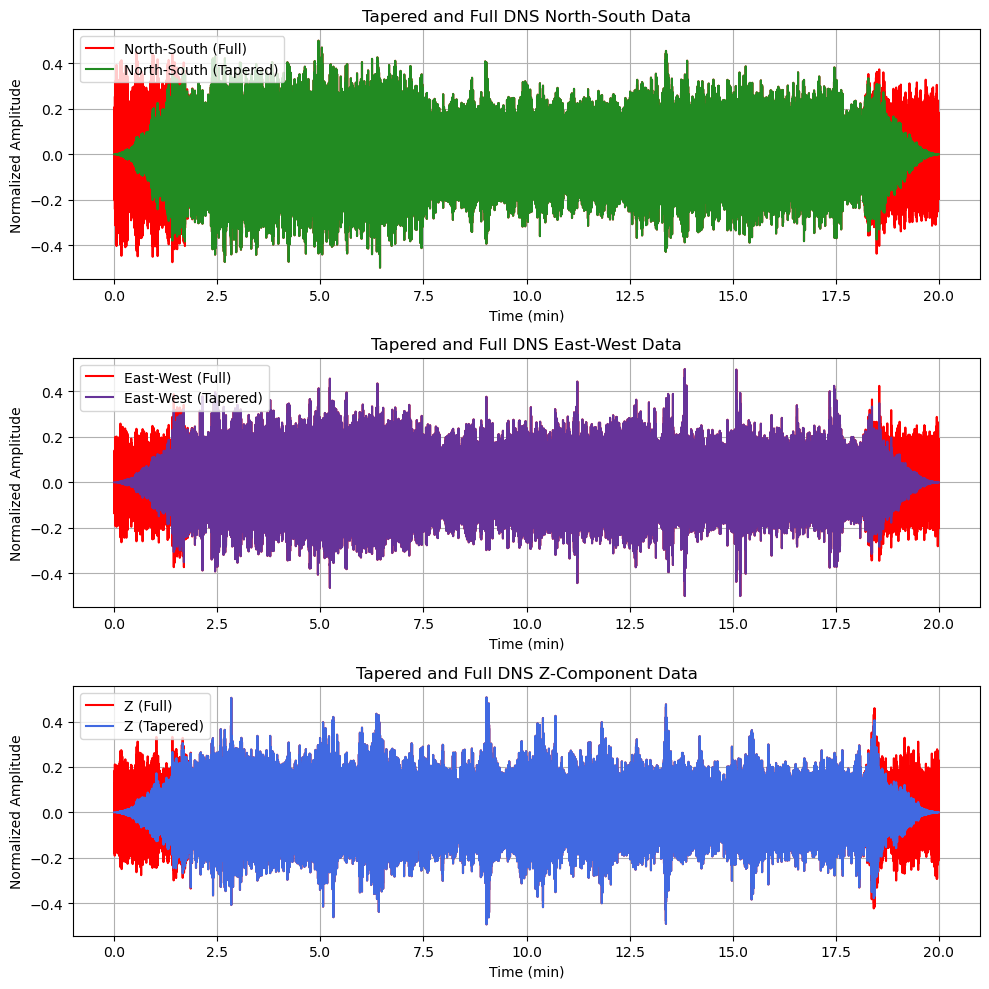

In [4]:
# Taper the time series:
def apply_hann_window(data, NS_column, EW_column, Z_column, taper_fraction = 0.1):
    """Taper edges of time series with Hann window
    taper_fraction = 0.1 will start taper at 10% from edges"""
    n= len(data)
    taper_length = int(n * taper_fraction)

    # NS Data:
    # Create a copy of the data
    NS_windowed_data = data[NS_column].copy()
    NS_windowed_data = NS_windowed_data.astype(float) # needed for FFT code to work properly later on
    # Apply Hann window to the left edge
    NS_left_window = np.hanning(2 * taper_length)[:taper_length]
    NS_windowed_data.iloc[:taper_length] *= NS_left_window
    # Apply Hann window to the right edge
    NS_right_window = np.hanning(2 * taper_length)[taper_length:]
    NS_windowed_data.iloc[-taper_length:] *= NS_right_window

    # EW Data:
    # Create a copy of the data
    EW_windowed_data = data[EW_column].copy()
    EW_windowed_data = EW_windowed_data.astype(float) 
    # Apply Hann window to the left edge
    EW_left_window = np.hanning(2 * taper_length)[:taper_length]
    EW_windowed_data.iloc[:taper_length] *= EW_left_window
    # Apply Hann window to the right edge
    EW_right_window = np.hanning(2 * taper_length)[taper_length:]
    EW_windowed_data.iloc[-taper_length:] *= EW_right_window

    # Z Data:
    Z_windowed_data = data[Z_column].copy()
    Z_windowed_data = Z_windowed_data.astype(float) 
    # Apply Hann window to the left edge
    Z_left_window = np.hanning(2 * taper_length)[:taper_length]
    Z_windowed_data.iloc[:taper_length] *= Z_left_window
    # Apply Hann window to the right edge
    Z_right_window = np.hanning(2 * taper_length)[taper_length:]
    Z_windowed_data.iloc[-taper_length:] *= Z_right_window
    
    return NS_windowed_data, EW_windowed_data, Z_windowed_data
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# df:
NS_hann_result_df, EW_hann_result_df, Z_hann_result_df = apply_hann_window(df, 'NS_Normalized_Shifted', 'EW_Normalized_Shifted', 'Z_Normalized_Shifted')
# df2:
NS_hann_result_df2, EW_hann_result_df2, Z_hann_result_df2 = apply_hann_window(df2, 'NS_Normalized_Shifted', 'EW_Normalized_Shifted', 'Z_Normalized_Shifted')
# df3:
NS_hann_result_df3, EW_hann_result_df3, Z_hann_result_df3 = apply_hann_window(df3, 'NS_Normalized_Shifted', 'EW_Normalized_Shifted', 'Z_Normalized_Shifted')
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
NS_hann_results = [NS_hann_result_df, NS_hann_result_df2, NS_hann_result_df3]
EW_hann_results = [EW_hann_result_df, EW_hann_result_df2, EW_hann_result_df3]
Z_hann_results = [Z_hann_result_df, Z_hann_result_df2, Z_hann_result_df3]

# Plot tapered data with full data for all dataframes:
for i, dframe in enumerate(dataframes):
    if i == 0:
        print("dataframe: df")
    else:
        print(f"dataframe: df{i+1}")
    # Plot:
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    time_minutes = dframe['time (s)']/60
    # North-South data:
    axes[0].plot(time_minutes, dframe['NS_Normalized_Shifted'], label='North-South (Full)', color='red')
    axes[0].plot(time_minutes, NS_hann_results[i], label='North-South (Tapered)', color='forestgreen') # make sure step for time_minutes=decimation_factor
    axes[0].set_ylabel('Normalized Amplitude')
    axes[0].set_title('Tapered and Full DNS North-South Data')
    axes[0].set_xlabel('Time (min)')
    axes[0].legend(loc='upper left')
    axes[0].grid(True)
    
    # East-West data:
    axes[1].plot(time_minutes, dframe['EW_Normalized_Shifted'], label='East-West (Full)', color='red')
    axes[1].plot(time_minutes, EW_hann_results[i], label='East-West (Tapered)', color='rebeccapurple')
    axes[1].set_ylabel('Normalized Amplitude')
    axes[1].set_title('Tapered and Full DNS East-West Data')
    axes[1].set_xlabel('Time (min)')
    axes[1].legend(loc='upper left')
    axes[1].grid(True)
    
    # Z data:
    axes[2].plot(time_minutes, dframe['Z_Normalized_Shifted'], label='Z (Full)', color='red')
    axes[2].plot(time_minutes, Z_hann_results[i], label='Z (Tapered)', color='royalblue')
    axes[2].set_ylabel('Normalized Amplitude')
    axes[2].set_title('Tapered and Full DNS Z-Component Data')
    axes[2].set_xlabel('Time (min)')
    axes[2].legend(loc='upper left')
    #axes[2].set_xlim(-0.001,0.01)
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()

***
### Fast Fourier Transform
- Goal: Decrease frequency resolution

In [6]:
# Define helper functions:
# Hann window one column at a time:
def apply_hann_window1(data, column, taper_fraction = 0.1):
    """Taper edges of time series with Hann window
    taper_fraction = 0.1 will start taper at 10% from edges"""
    n= len(data)
    taper_length = int(n * taper_fraction)
    
    # Create a copy of the data
    windowed_data = data[column].copy()
    windowed_data = windowed_data.astype(float) # needed for FFT code to work properly
    
    # Apply Hann window to the left edge
    left_window = np.hanning(2 * taper_length)[:taper_length]
    windowed_data[:taper_length] *= left_window
    
    # Apply Hann window to the right edge
    right_window = np.hanning(2 * taper_length)[taper_length:]
    windowed_data[-taper_length:] *= right_window
    
    return windowed_data

#print(type(apply_hann_window1(df, "NS_Normalized_Shifted")))

def calculate_coherent_gain(data, taper_fraction=0.1):
    """Calculate coherent gain for partial Hann taper"""
    n=len(data)
    taper_length = int(n * taper_fraction)
    
    # Create the full window
    window = np.ones(n)
    
    # Left taper
    left_window = np.hanning(2 * taper_length)[:taper_length]
    window[:taper_length] = left_window
    
    # Right taper
    right_window = np.hanning(2 * taper_length)[taper_length:]
    window[-taper_length:] = right_window
    
    # Coherent gain is the mean
    coherent_gain = np.mean(window)
    
    return coherent_gain

##### FFT With Frequency Bin Averaging:

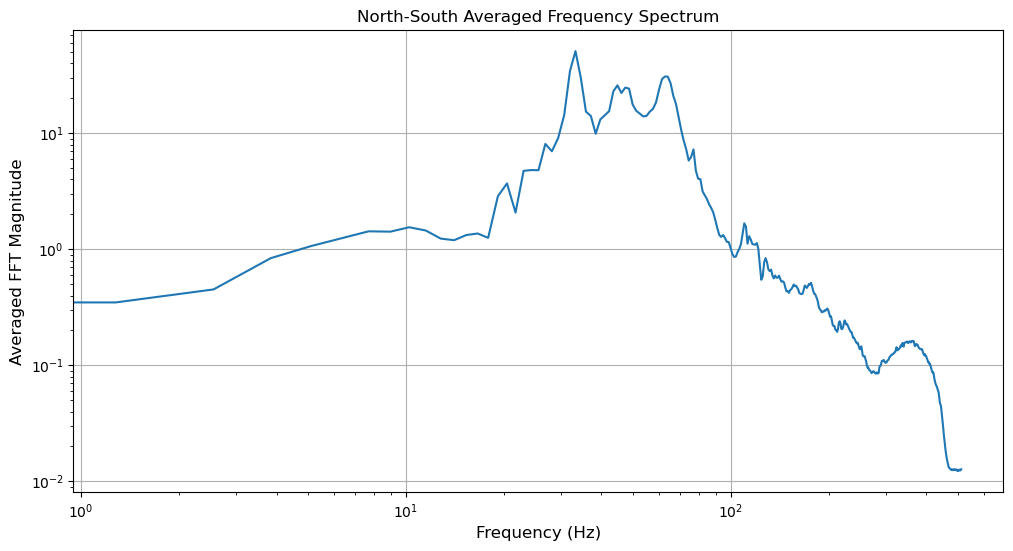

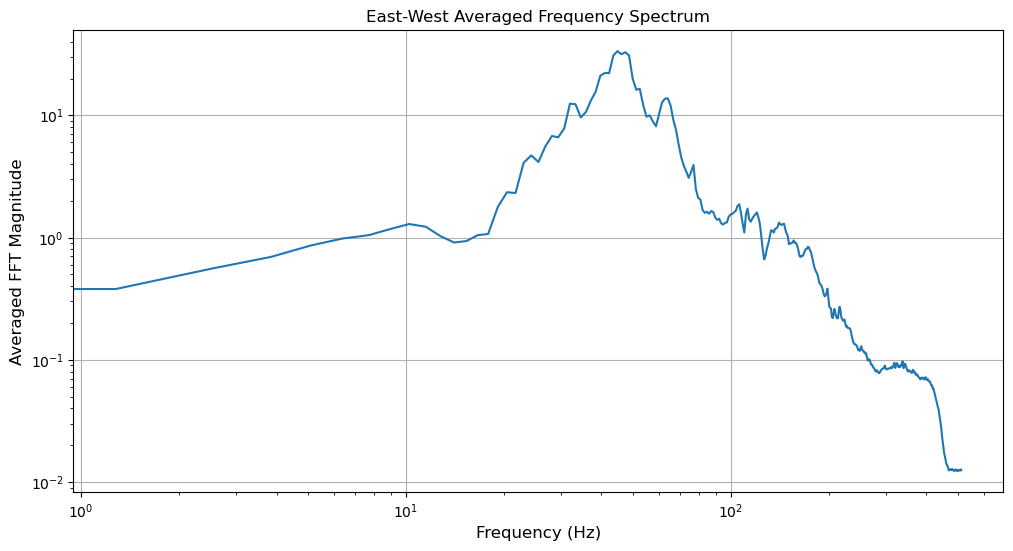

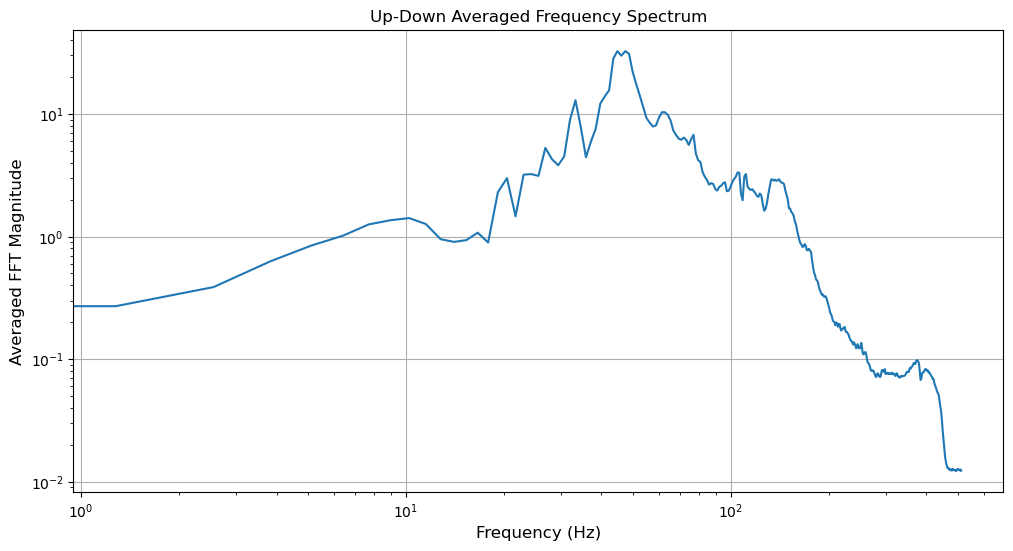

In [8]:
def plot_averaged_fft(data, column, sr, segment_size, title=''):
    """Plot FFT with frequency bin averaging 
    data: pandas DataFrame
    column: relevant data column from data, string
    sr: Sampling rate in Hz
    segment_size:segment size for averaging, int
    title: plot title, str"""
    # Goal: decrease frequency resolution of the FFT
    # Signal parameters
    T = 1 / sr  # Sampling period
    # signal x:
    x = data[column].values
    N = len(x)
    
    # Parameters for averaging
    overlap = 0.5   # 50% overlap
    step_size = int(segment_size * (1 - overlap))
    
    # Calculate number of segments
    num_segments = (N - segment_size) // step_size + 1
    
    # Initialize array to store summed FFT results
    avg_fft_magnitude = np.zeros(segment_size // 2 + 1) # only need one side for real input
    
    for i in range(num_segments):
        start = i * step_size
        end = start + segment_size
        segment = x[start:end]
        
        # apply a Hanning window to the segment to reduce spectral leakage
        window = np.hanning(segment_size)
        windowed_segment = segment * window
        
        # Compute FFT of the segment
        segment_fft = scipy.fft.rfft(windowed_segment, segment_size)
        
        # Get the magnitude of the positive frequency side
        #segment_magnitude = np.abs(segment_fft)[:segment_size // 2 + 1]
        segment_magnitude = np.abs(segment_fft)[:segment_size // 2 + 1] / np.sum(window) # window sum is for amplitude correction
        
        # Accumulate the magnitudes
        #avg_fft_magnitude += segment_magnitude 
        avg_fft_magnitude += segment_magnitude ** 2 #accumulate power
    
    # Calculate the mean magnitude
    #avg_fft_magnitude /= num_segments
    avg_fft_magnitude = np.sqrt(avg_fft_magnitude / num_segments) # don't take square root if want power spectral density instead
    
    # Get the frequency bins
    freqs = scipy.fft.rfftfreq(segment_size, T)[:segment_size // 2 + 1]
    
    # Plot the averaged frequency spectrum
    plt.figure(figsize=(12, 6))
    #plt.plot(freqs, avg_fft_magnitude)
    plt.loglog(freqs, avg_fft_magnitude)
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Averaged FFT Magnitude', fontsize=12)
    plt.title(title)
    plt.grid(True)
    plt.show()

    return freqs, avg_fft_magnitude
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Try with non-normalized data:
result1 = plot_averaged_fft(df, 'NS_Detrended', sr=original_sampling_rate, segment_size=800, title='North-South Averaged Frequency Spectrum')
result2 = plot_averaged_fft(df, 'EW_Detrended', sr=original_sampling_rate, segment_size=800, title='East-West Averaged Frequency Spectrum')
result3 = plot_averaged_fft(df, 'Z_Detrended', sr=original_sampling_rate, segment_size=800, title='Up-Down Averaged Frequency Spectrum')

##### Power Spectral Density With Welch's Method:
- Change the scaling parameter in welch() from 'density' to 'spectrum' to plot a squared magnitude spectrum instead

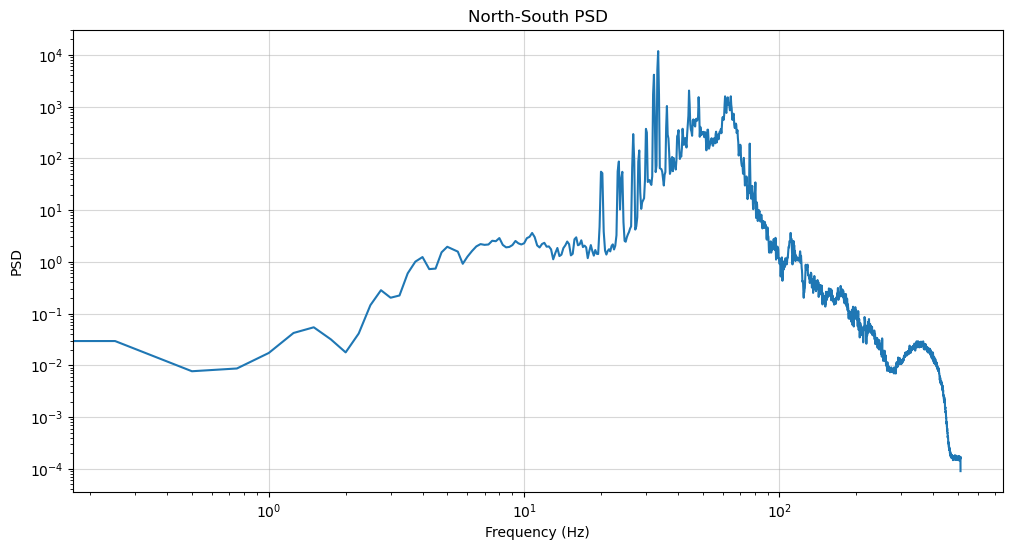

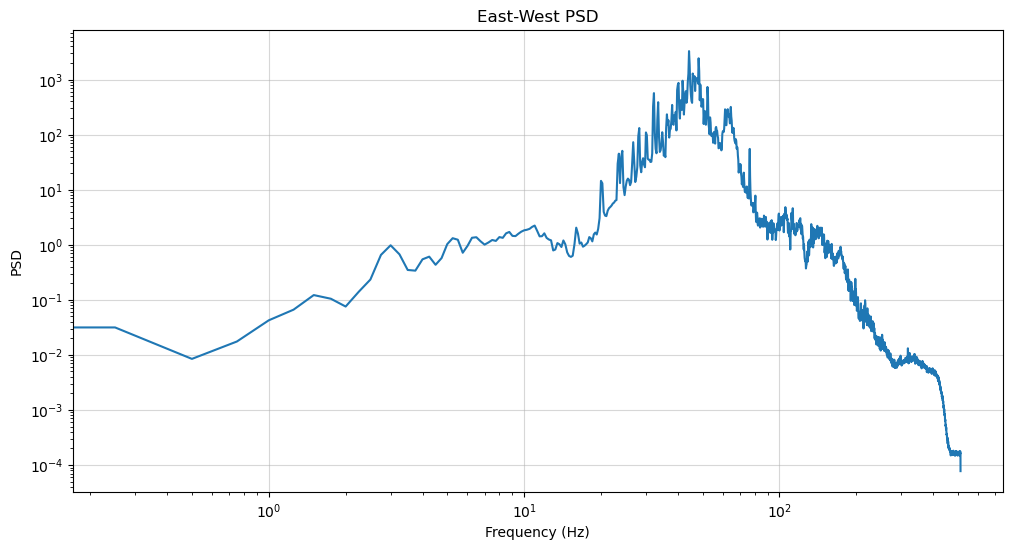

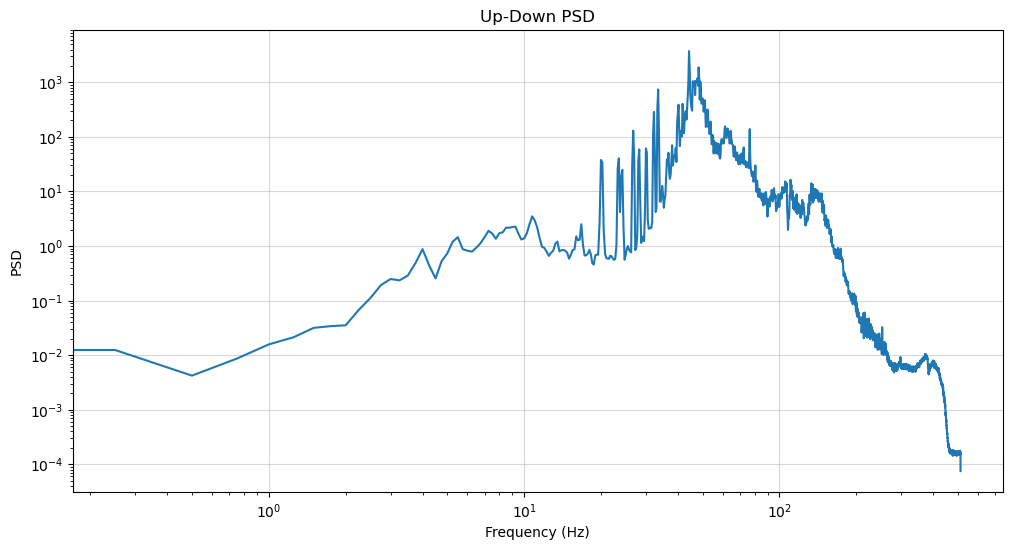

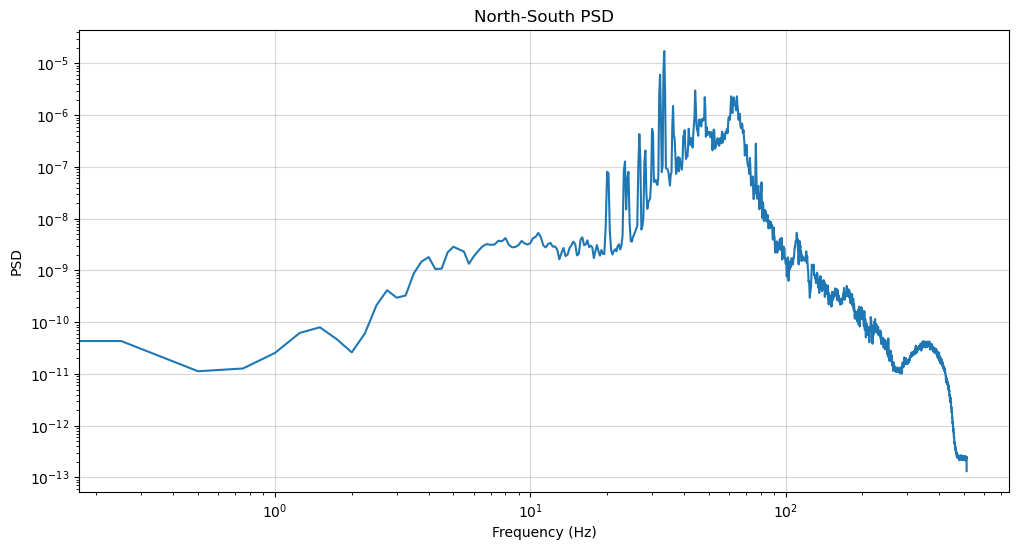

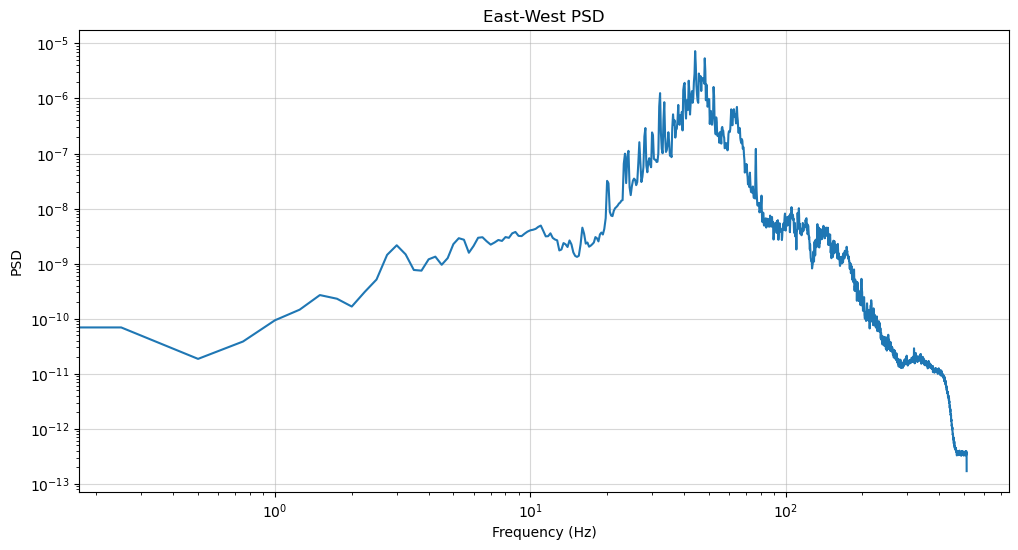

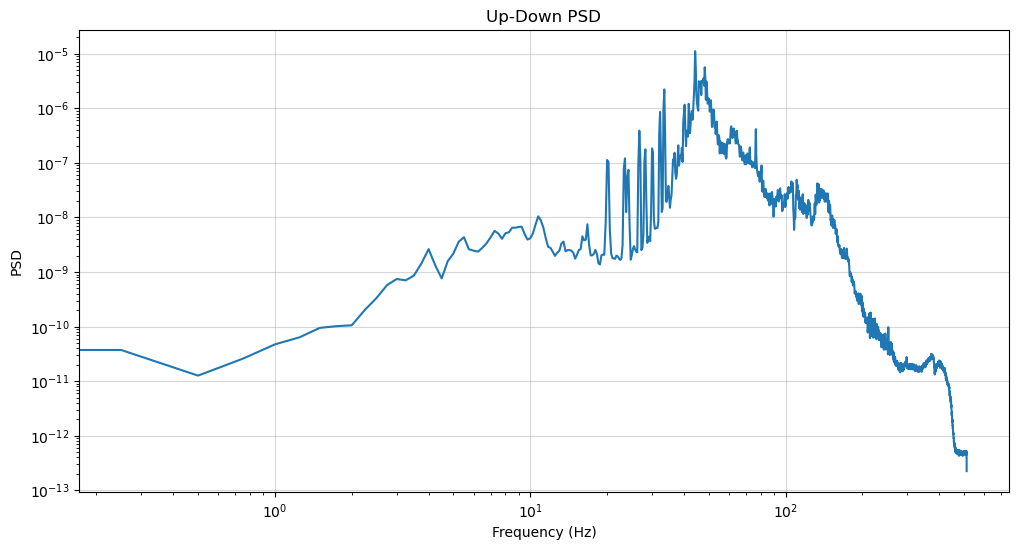

In [10]:
# Trying power spectral density:
def welch_psd(data, column, sr, title, segment_size, window='hann'):
    """data: pandas DataFrame
    column: relevant data column from data, str
    sr: Sampling rate in Hz
    title: title for PSD plot, str
    segment_size: length of each segment
    window: desired window to use"""
    
    overlap = segment_size//2 # number of points to overlap between segments, here is 50% overlap
    freqs, psd = welch(data[column].values, fs=sr, nperseg=segment_size, noverlap=overlap, window=window, scaling='density')

    # Plot:
    plt.figure(figsize=(12,6))
    #plt.plot(freqs,psd)
    plt.loglog(freqs, psd)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title(title)
    plt.grid(True, alpha=0.5)
    #plt.ylim(bottom=10**-4)
    plt.show()

    return freqs, psd
    
# Results using non-normalized data:
freqs_NS, psd_NS = welch_psd(df, 'NS_Detrended', original_sampling_rate, 'North-South PSD', segment_size=4096) # using non-normalized data here
freqs_EW, psd_EW = welch_psd(df, 'EW_Detrended', original_sampling_rate, 'East-West PSD', segment_size=4096)
freqs_Z, psd_Z = welch_psd(df, 'Z_Detrended', original_sampling_rate, 'Up-Down PSD', segment_size=4096)

# Results using normalized (DNS) data:
freqs_NS_, psd_NS_ = welch_psd(df, 'NS_Normalized_Shifted', original_sampling_rate, 'North-South PSD', segment_size=4096)
freqs_EW_, psd_EW_ = welch_psd(df, 'EW_Normalized_Shifted', original_sampling_rate, 'East-West PSD', segment_size=4096)
freqs_Z_, psd_Z_ = welch_psd(df, 'Z_Normalized_Shifted', original_sampling_rate, 'Up-Down PSD', segment_size=4096)

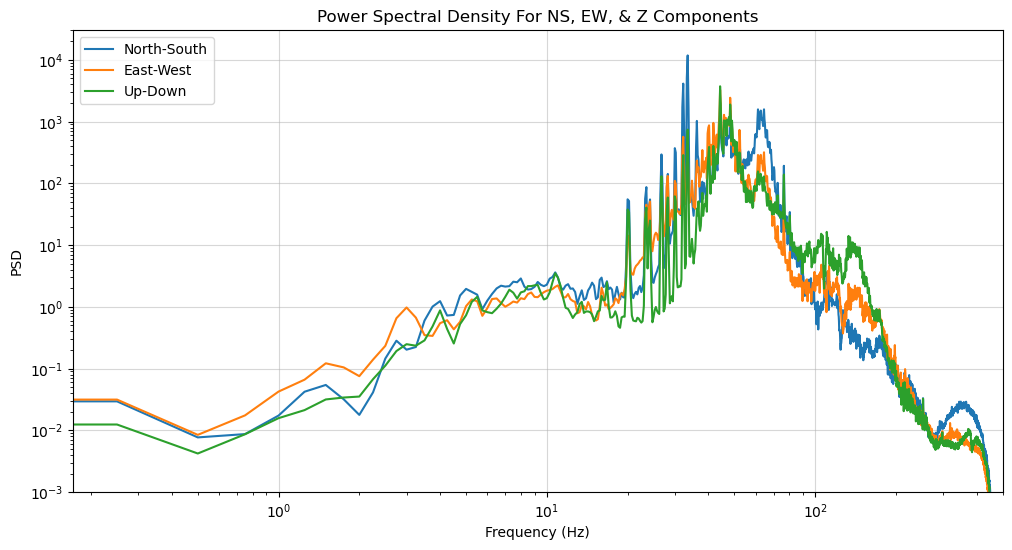

In [11]:
# PSD plot for all directions using non-nomalized data:
fig, ax = plt.subplots(figsize=(12,6))
ax.loglog(freqs_NS, psd_NS, label='North-South')
ax.loglog(freqs_EW, psd_EW, label='East-West')
ax.loglog(freqs_Z, psd_Z, label='Up-Down')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_ylim(bottom=0.001)
ax.set_xlim(right=500)
ax.set_title('Power Spectral Density For NS, EW, & Z Components')
plt.grid(True, alpha=0.5)
ax.legend(loc='upper left')
plt.show()
# Units?

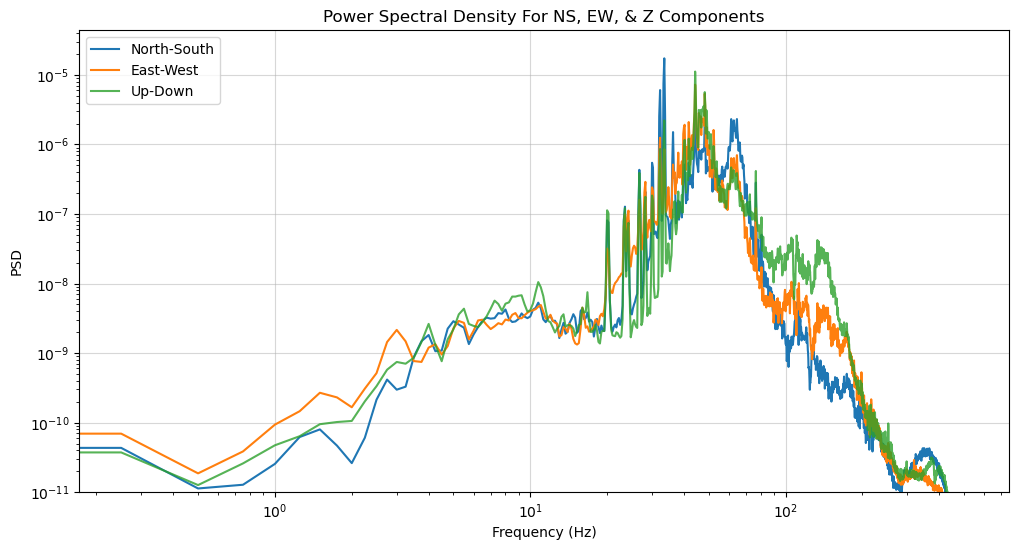

In [12]:
# PSD plot for all directions using normalized (DNS) data as input:
figg, axx = plt.subplots(figsize=(12,6))
axx.loglog(freqs_NS_, psd_NS_, label='North-South')#, color='green')
axx.loglog(freqs_EW_, psd_EW_, label='East-West')#, color='blue')
axx.loglog(freqs_Z_, psd_Z_, label='Up-Down', alpha=0.8)#, color='magenta')
axx.set_xlabel('Frequency (Hz)')
axx.set_ylabel('PSD')
axx.set_ylim(bottom=10**-11)
#axx.set_xlim(right=500)
axx.set_title('Power Spectral Density For NS, EW, & Z Components')
plt.grid(True, alpha=0.5)
axx.legend(loc='upper left')
plt.show()

***
#### Horizontal-to-Vertical-Spectral-Ratio (HVSR):
- Method 1: FFT-based HVSR
    - Based on original version of FFT code
    - Relies on Savitzky-Golay filter for smoothing
- Method 2: Segmented FFT-based HVSR
    - Based on plot_averaged_fft approach
- Method 3: PSD-based HVSR (Welch's Method)
    - Can also use Savitzky-Golay filter here for smoother result, but less necessary than in Method 1

Full data peak frequency: 28.427500000000002 Hz
Full data peak H/V: 6.045428195377586


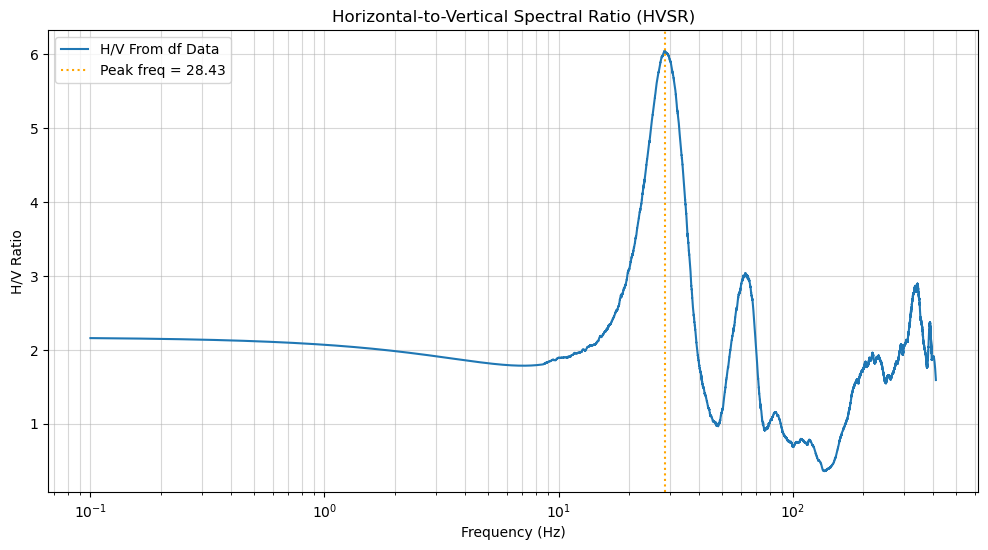

In [14]:
# Option 1: FFT-based HVSR
def H_V_ratio_fft(data_ns, column_ns, data_ew, column_ew, data_z, column_z, sr, apply_window=True, freq_min=0.1, freq_max=None, combine_method='rms'):
    """Compute Horizontal-to-Vertical Spectral Ratio (HVSR) using FFT.
    data_ns: pandas DataFrame containing North-South component
    column_ns: column name for NS component, string
    data_ew: pandas DataFrame containing East-West component
    column_ew: column name for EW component, string
    data_z: pandas DataFrame containing vertical component
    column_z: column name for Z component, string
    sr: sampling rate in Hz
    apply_window: whether to apply partial Hann taper, bool (default True)
    freq_min: minimum frequency to include in output, Hz (default 0.1)
    freq_max: maximum frequency to include, Hz (default 80% of Nyquist)
    combine_method: how to combine NS and EW horizontals:
                    'rms' for geometric mean: sqrt((ns**2 + ew**2) / 2)
                    'vector' for vector magnitude: sqrt(ns**2 + ew**2)

    Returns:
    freqs: frequency array (Hz), masked to [freq_min, freq_max]
    hvsr: H/V spectral ratio, masked to [freq_min, freq_max]"""
    n = len(data_ns)

    if freq_max is None:
        freq_max = 0.8 * (sr / 2) # 80% of Nyquist

    # Apply window if requested
    if apply_window:
        windowed_data_ns = apply_hann_window1(data_ns, column_ns, taper_fraction=0.1).values
        windowed_data_ew = apply_hann_window1(data_ew, column_ew, taper_fraction=0.1).values
        windowed_data_z  = apply_hann_window1(data_z,  column_z,  taper_fraction=0.1).values
        coherent_gain = calculate_coherent_gain(data_ns[column_ns], taper_fraction=0.1)
    else:
        windowed_data_ns = data_ns[column_ns].values
        windowed_data_ew = data_ew[column_ew].values
        windowed_data_z  = data_z[column_z].values
        coherent_gain= 1.0

    #Compute FFTs
    fft_ns = scipy.fft.rfft(windowed_data_ns)
    fft_ew = scipy.fft.rfft(windowed_data_ew)
    fft_z  = scipy.fft.rfft(windowed_data_z)
    freqs  = scipy.fft.rfftfreq(n, d=1/sr)

    # Compute magnitudes WITH coherent gain correction
    mag_ns = np.abs(fft_ns) / (n * coherent_gain)
    mag_ew = np.abs(fft_ew) / (n * coherent_gain)
    mag_z  = np.abs(fft_z)  / (n * coherent_gain)

    # Double AC components for one-sided spectrum 
    mag_ns[1:] *= 2.0
    mag_ew[1:] *= 2.0
    mag_z[1:]  *= 2.0

    # Undo doubling for Nyquist if even length
    if n % 2 == 0:
        mag_ns[-1] /= 2.0
        mag_ew[-1] /= 2.0
        mag_z[-1]  /= 2.0

    # Combine horizontal components
    if combine_method == 'rms':
        mag_horizontal = np.sqrt((mag_ns**2 + mag_ew**2) / 2)  # geometric mean (seismology standard)
    elif combine_method == 'vector':
        mag_horizontal = np.sqrt(mag_ns**2 + mag_ew**2)        # vector magnitude
    else:
        raise ValueError("combine_method must be 'rms' or 'vector'")

    # Apply frequency mask first, then compute threshold within that range:
    freq_mask = (freqs >= freq_min) & (freqs <= freq_max)

    # Compute division threshold within the masked frequency range only
    z_threshold = np.max(mag_z[freq_mask]) * 1e-8

    # Compute HVSR with threshold to avoid division by near-zero values
    hvsr = np.zeros_like(mag_horizontal)
    mask = mag_z > z_threshold
    hvsr[mask] = mag_horizontal[mask] / mag_z[mask]

    return freqs[freq_mask], hvsr[freq_mask]
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Get result for non-normalized df data:
freqs1, hvsr1 = H_V_ratio_fft(df, 'NS_Detrended', df, 'EW_Detrended', df, 'Z_Detrended', original_sampling_rate)
# Apply smoothing with Savitzky-Golay filter
hvsr1_smooth = savgol_filter(hvsr1, window_length=20481, polyorder=2) # window_length should be an odd integer
# Find main peak in given frequency range:
peak_idx = np.argmax(hvsr1_smooth[(freqs1 > 10) & (freqs1 < 50)])
peak_freq = freqs1[(freqs1 > 10) & (freqs1 < 50)][peak_idx]
peak_value = hvsr1_smooth[(freqs1 > 10) & (freqs1 < 50)][peak_idx]
print(f"Full data peak frequency: {peak_freq} Hz")
print(f"Full data peak H/V: {peak_value}")

# Plot:
plt.figure(figsize=(12, 6))
plt.semilogx(freqs1, hvsr1_smooth, label="H/V From df Data")
plt.xlabel('Frequency (Hz)')
plt.ylabel('H/V Ratio')
plt.title('Horizontal-to-Vertical Spectral Ratio (HVSR)')
plt.grid(True, which="both", alpha=0.5)
plt.axvline(x=peak_freq, linestyle=":", color='orange', label=f'Peak freq = {peak_freq:.2f}') 
plt.legend(loc='upper left')
plt.show()

In [47]:
# Option 2: Segmented FFT-based HVSR
# Does not give very smooth curve
def H_V_ratio_fft_segmented(data_ns, column_ns, data_ew, column_ew, data_z, column_z, sr, segment_size=1000, overlap=0.5,
                              freq_min=0.1, freq_max=None, combine_method='rms'):
    """Compute HVSR using segmented FFT averaging (matches plot_averaged_fft approach).
    Computes H/V ratio per segment, then RMS-averages across segments.
    This follows the SESAME guideline approach of averaging ratios, not spectra.
    
    data_ns: pandas DataFrame containing North-South component
    column_ns: column name for NS component, string
    data_ew: pandas DataFrame containing East-West component
    column_ew: column name for EW component, string
    data_z: pandas DataFrame containing vertical component
    column_z: column name for Z component, string
    sr: sampling rate in Hz
    segment_size: length of each FFT segment (controls frequency resolution), int
    overlap: fractional overlap between segments, float (default 0.5 = 50%)
    freq_min: minimum frequency to include in output, Hz (default 0.1)
    freq_max: maximum frequency to include, Hz (default 80% of Nyquist)
    combine_method: how to combine NS and EW horizontals:
                    'rms' for geometric mean: sqrt((ns² + ew²) / 2) 
                    'vector' for vector magnitude: sqrt(ns² + ew²)
    Returns
    freqs: frequency array (Hz), masked to [freq_min, freq_max]
    hvsr: RMS-averaged H/V spectral ratio
    hvsr_std : standard deviation across segments (measure of stability)"""
    if freq_max is None:
        freq_max = 0.8 * (sr / 2)

    # Extract signal arrays
    x_ns = data_ns[column_ns].values
    x_ew = data_ew[column_ew].values
    x_z  = data_z[column_z].values
    N    = len(x_ns)

    # Segment parameters
    step_size = int(segment_size * (1 - overlap))
    num_segments = (N - segment_size) // step_size + 1
    n_freqs= segment_size // 2 + 1

    # Hann window for each segment
    window = np.hanning(segment_size)
    coherent_gain = np.mean(window)  # for amplitude correction

    # Accumulate squared HVSR per segment (for RMS averaging)
    hvsr_sq_accum = np.zeros(n_freqs)
    hvsr_segments = []  # store per-segment ratios for std calculation

    for i in range(num_segments):
        start = i * step_size
        end   = start + segment_size

        # Extract and window each segment
        seg_ns = x_ns[start:end] * window
        seg_ew = x_ew[start:end] * window
        seg_z  = x_z[start:end]  * window

        # Compute FFT for each component
        fft_ns = scipy.fft.rfft(seg_ns, segment_size)
        fft_ew = scipy.fft.rfft(seg_ew, segment_size)
        fft_z  = scipy.fft.rfft(seg_z,  segment_size)

        # Compute magnitudes with coherent gain correction
        mag_ns = np.abs(fft_ns) / (segment_size * coherent_gain)
        mag_ew = np.abs(fft_ew) / (segment_size * coherent_gain)
        mag_z  = np.abs(fft_z)  / (segment_size * coherent_gain)

        # Double AC components for one-sided spectrum
        mag_ns[1:] *= 2.0
        mag_ew[1:] *= 2.0
        mag_z[1:]  *= 2.0

        # Undo doubling for Nyquist bin if even
        if segment_size % 2 == 0:
            mag_ns[-1] /= 2.0
            mag_ew[-1] /= 2.0
            mag_z[-1]  /= 2.0

        # Combine horizontal components
        if combine_method == 'rms':
            mag_horizontal = np.sqrt((mag_ns**2 + mag_ew**2) / 2)
        elif combine_method == 'vector':
            mag_horizontal = np.sqrt(mag_ns**2 + mag_ew**2)
        else:
            raise ValueError("combine_method must be 'rms' or 'vector'")

        # Compute per-segment HVSR with threshold guard
        z_threshold = np.max(mag_z) * 1e-8
        hvsr_seg = np.zeros(n_freqs)
        valid = mag_z > z_threshold
        hvsr_seg[valid] = mag_horizontal[valid] / mag_z[valid]

        # Accumulate squared ratios for RMS averaging
        hvsr_sq_accum += hvsr_seg**2
        hvsr_segments.append(hvsr_seg)

    # RMS average across segments
    hvsr = np.sqrt(hvsr_sq_accum / num_segments)

    # Standard deviation across segments (stability indicator)
    hvsr_stack = np.array(hvsr_segments)  # shape: (num_segments, n_freqs)
    hvsr_std   = np.std(hvsr_stack, axis=0)

    # Frequency bins
    freqs = scipy.fft.rfftfreq(segment_size, d=1/sr)

    # Apply frequency mask
    freq_mask = (freqs >= freq_min) & (freqs <= freq_max)

    return freqs[freq_mask], hvsr[freq_mask], hvsr_std[freq_mask]
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# freqs_segmented1, HV_segmented1, HV_std1 = H_V_ratio_fft_segmented(df, 'NS_Detrended', df, 'EW_Detrended', df, 'Z_Detrended', original_sampling_rate,
#                                                                   segment_size=250, freq_max=100)
# # Try SG filter here too?
# #HV_segmented1_smooth = savgol_filter(HV_segmented1, window_length=5, polyorder=2) # window_length should be an odd integer
# # Find main peak:
# peak_idx_s = np.argmax(HV_segmented1[(freqs_segmented1 > 10) & (freqs_segmented1 < 50)])
# peak_freq_s = freqs_segmented1[(freqs_segmented1 > 10) & (freqs_segmented1 < 50)][peak_idx_s]
# peak_value_s = HV_segmented1[(freqs_segmented1 > 10) & (freqs_segmented1 < 50)][peak_idx_s]
# print(f"Full data peak frequency: {peak_freq_s} Hz")
# print(f"Full data peak H/V: {peak_value_s}")

# # Plot:
# plt.figure(figsize=(12, 6))
# plt.semilogx(freqs_segmented1, HV_segmented1, label="H/V From df Data")
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('H/V Ratio')
# plt.title('Horizontal-to-Vertical Spectral Ratio (HVSR)')
# plt.grid(True, which="both", alpha=0.5)
# plt.axvline(x=peak_freq_s, linestyle=":", color='orange', label=f'Peak freq = {peak_freq_s:.2f}') 
# plt.legend(loc='upper left')
# plt.show()

Full data peak frequency: 32.768 Hz
Full data peak H/V: 2.878664415842855


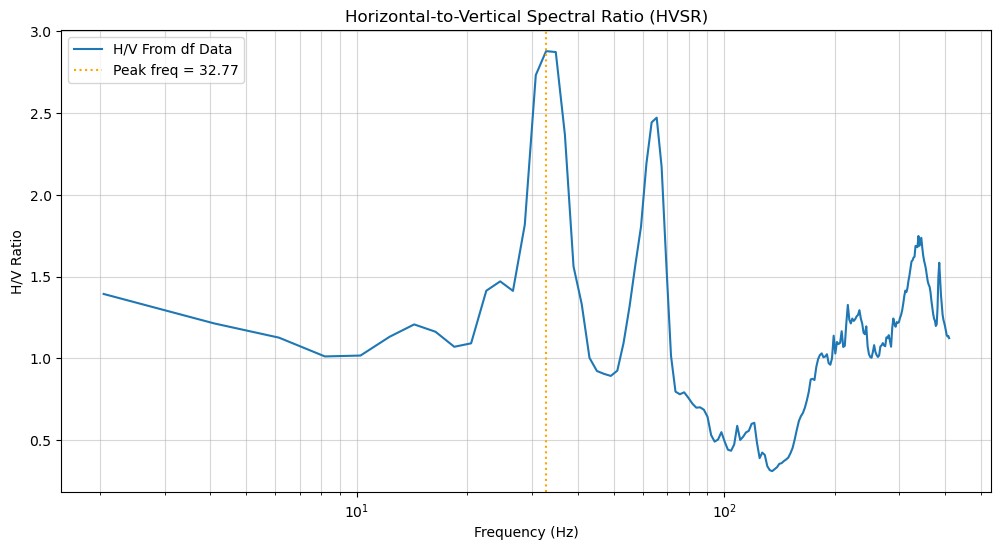

In [16]:
# Option 3: PSD-based HVSR (Welch's method)
def H_V_ratio_psd(data_ns, column_ns, data_ew, column_ew, data_z, column_z, sr, segment_size=1000, freq_min=0.1, freq_max=None, combine_method='rms', 
                  window='hann'):
    """Compute Horizontal-to-Vertical Spectral Ratio (HVSR) using Welch PSD. Welch averaging reduces noise and produces a smoother ratio curve.
    data_ns: pandas DataFrame containing North-South component
    column_ns: column name for NS component, string
    data_ew: pandas DataFrame containing East-West component
    column_ew: column name for EW component, string
    data_z: pandas DataFrame containing vertical component
    column_z: column name for Z component, string
    sr: sampling rate in Hz
    segment_size : length of each Welch segment (controls freq resolution), int
    freq_min: minimum frequency to include in output, Hz (default 0.1)
    freq_max: maximum frequency to include, Hz (default 80% of Nyquist)
    combine_method: how to combine NS and EW horizontals:
                    'rms' for geometric mean: sqrt((psd_ns + psd_ew) / 2)
                    'vector' for sum: psd_ns + psd_ew
    window: window function for Welch (default 'hann')

    Returns
    freqs: frequency array (Hz), masked to [freq_min, freq_max]
    hvsr: H/V spectral ratio, masked to [freq_min, freq_max]
    psd_ns, psd_ew, psd_z : individual component PSDs"""
    if freq_max is None:
        freq_max = 0.8 * (sr / 2)

    overlap = segment_size // 2  # 50% overlap

    #Compute Welch PSD for each component
    freqs, psd_ns = welch(data_ns[column_ns].values, fs=sr, nperseg=segment_size, noverlap=overlap, window=window)
    freqs, psd_ew = welch(data_ew[column_ew].values, fs=sr, nperseg=segment_size, noverlap=overlap, window=window)
    freqs, psd_z  = welch(data_z[column_z].values,   fs=sr, nperseg=segment_size, noverlap=overlap, window=window)

    # Combine horizontal PSDs
    # Note: working in power domain, so RMS = sqrt(mean(power))
    if combine_method == 'rms':
        psd_horizontal = np.sqrt((psd_ns + psd_ew) / 2) # geometric mean amplitude
        psd_vertical   = np.sqrt(psd_z)
    elif combine_method == 'vector':
        psd_horizontal = np.sqrt(psd_ns + psd_ew) # vector amplitude
        psd_vertical   = np.sqrt(psd_z)
    else:
        raise ValueError("combine_method must be 'rms' or 'vector'")

    # Apply frequency mask first
    freq_mask = (freqs >= freq_min) & (freqs <= freq_max)

    # Compute threshold within masked range only
    z_threshold = np.max(psd_vertical[freq_mask]) * 1e-8

    # Compute HVSR
    hvsr = np.zeros_like(psd_horizontal)
    mask = psd_vertical > z_threshold
    hvsr[mask] = psd_horizontal[mask] / psd_vertical[mask]

    return freqs[freq_mask], hvsr[freq_mask], psd_ns[freq_mask], psd_ew[freq_mask], psd_z[freq_mask]
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
freqs1_psd, hvsr1_psd, _, _, _ = H_V_ratio_psd(df, 'NS_Detrended', df, 'EW_Detrended', df, 'Z_Detrended', original_sampling_rate, segment_size=500)
# Try SG filter here too?
#hvsr1_psd_smooth = savgol_filter(hvsr1_psd, window_length=15, polyorder=2) # window_length should be an odd integer
# Find main peak:
peak_idx_psd = np.argmax(hvsr1_psd[(freqs1_psd > 10) & (freqs1_psd < 50)])
peak_freq_psd = freqs1_psd[(freqs1_psd > 10) & (freqs1_psd < 50)][peak_idx_psd]
peak_value_psd = hvsr1_psd[(freqs1_psd > 10) & (freqs1_psd < 50)][peak_idx_psd]
print(f"Full data peak frequency: {peak_freq_psd} Hz")
print(f"Full data peak H/V: {peak_value_psd}")

# Plot:
plt.figure(figsize=(12, 6))
plt.semilogx(freqs1_psd, hvsr1_psd, label="H/V From df Data")
plt.xlabel('Frequency (Hz)')
plt.ylabel('H/V Ratio')
plt.title('Horizontal-to-Vertical Spectral Ratio (HVSR)')
plt.grid(True, which="both", alpha=0.5)
plt.axvline(x=peak_freq_psd, linestyle=":", color='orange', label=f'Peak freq = {peak_freq_psd:.2f}') 
plt.legend(loc='upper left')
plt.show()

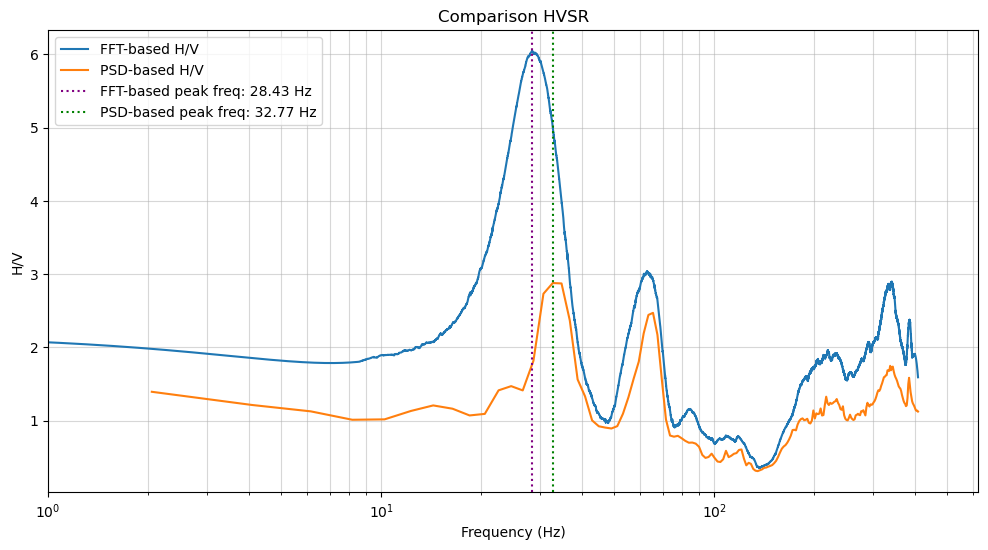

In [17]:
#HVSR Comparison Plot:
fig, ax = plt.subplots(figsize=(12,6))
ax.semilogx(freqs1, hvsr1_smooth, label="FFT-based H/V")
#ax.semilogx(freqs_segmented1, HV_segmented1, label="Segmented FFT-based H/V") # The other 2 results seem better
ax.semilogx(freqs1_psd, hvsr1_psd, label="PSD-based H/V")
ax.axvline(x=peak_freq, linestyle=":", color='purple', label=f'FFT-based peak freq: {peak_freq:.2f} Hz') 
#plt.axvline(x=peak_freq_s, linestyle=":", color='skyblue', label=f'Segmented FFT-based peak freq: {peak_freq_s:.2f}') 
ax.axvline(x=peak_freq_psd, linestyle=":", color='green', label=f'PSD-based peak freq: {peak_freq_psd:.2f} Hz') 
ax.set_ylabel("H/V")
ax.set_xlabel("Frequency (Hz)")
ax.legend(loc='upper left')
ax.set_title("Comparison HVSR")
ax.set_xlim(left=1)
plt.grid(True, which='both', alpha=0.5)
plt.show()

HVSR From Normalized, Detrended + Shifted df Data

PSD Method:
Full df data peak frequency: 34.816 Hz
Full df data peak H/V: 2.06060241002296

FFT Method:
Full df data peak frequency: 28.358333333333334 Hz
Full df data peak H/V: 4.854927117625102


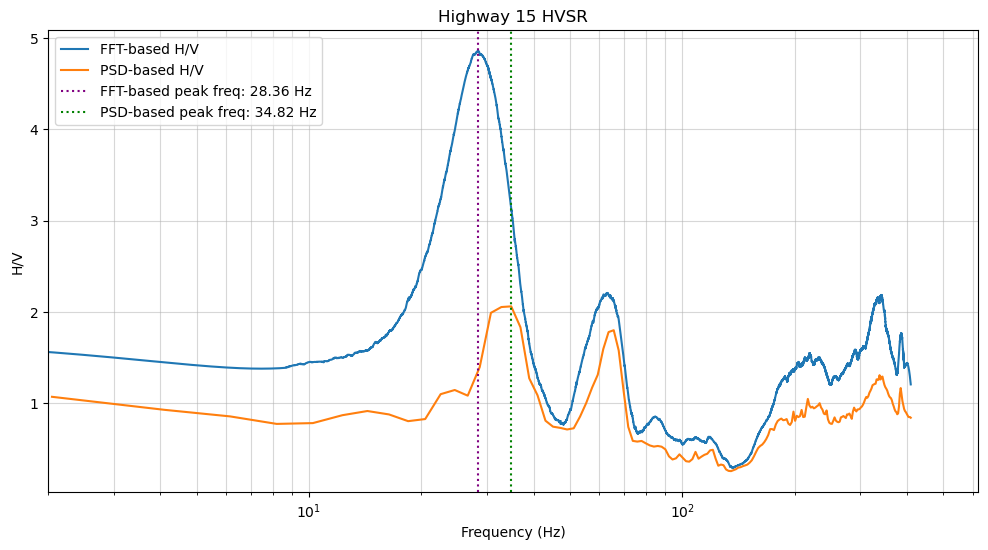

In [18]:
# HVSR with normalized df data:
print("HVSR From Normalized, Detrended + Shifted df Data")
print("")
# PSD-based result:
freqs_psd_df, hvsr_psd_df, _, _, _ = H_V_ratio_psd(df, 'NS_Normalized_Shifted', df, 'EW_Normalized_Shifted', df, 'Z_Normalized_Shifted', 
                                                   original_sampling_rate, segment_size=500)
# Find main peak:
peak_idx_psd_df = np.argmax(hvsr_psd_df[(freqs_psd_df > 10) & (freqs_psd_df < 50)])
peak_freq_psd_df = freqs_psd_df[(freqs_psd_df > 10) & (freqs_psd_df < 50)][peak_idx_psd_df]
peak_value_psd_df = hvsr_psd_df[(freqs_psd_df > 10) & (freqs_psd_df < 50)][peak_idx_psd_df]
print("PSD Method:")
print(f"Full df data peak frequency: {peak_freq_psd_df} Hz")
print(f"Full df data peak H/V: {peak_value_psd_df}")
print("")

# FFT-based result:
freqs_df, hvsr_df = H_V_ratio_fft(df, 'NS_Normalized_Shifted', df, 'EW_Normalized_Shifted', df, 'Z_Normalized_Shifted', original_sampling_rate)
hvsr_df_smooth = savgol_filter(hvsr_df, window_length=20481, polyorder=2) # window_length should be an odd integer
# Find main peak:
peak_idx_df = np.argmax(hvsr_df_smooth[(freqs_df > 10) & (freqs_df < 50)])
peak_freq_df = freqs_df[(freqs_df > 10) & (freqs_df < 50)][peak_idx_df]
peak_value_df = hvsr_df_smooth[(freqs_df > 10) & (freqs_df < 50)][peak_idx_df]
print("FFT Method:")
print(f"Full df data peak frequency: {peak_freq_df} Hz")
print(f"Full df data peak H/V: {peak_value_df}")

# Plot both results together:
figu, axe = plt.subplots(figsize=(12,6))
axe.semilogx(freqs_df, hvsr_df_smooth, label='FFT-based H/V')
axe.semilogx(freqs_psd_df, hvsr_psd_df, label='PSD-based H/V')
axe.axvline(x=peak_freq_df, linestyle=":", color='purple', label=f'FFT-based peak freq: {peak_freq_df:.2f} Hz') 
axe.axvline(x=peak_freq_psd_df, linestyle=":", color='green', label=f'PSD-based peak freq: {peak_freq_psd_df:.2f} Hz') 
axe.set_ylabel("H/V")
axe.set_xlabel("Frequency (Hz)")
axe.legend(loc='upper left')
axe.set_title("Highway 15 HVSR")
axe.set_xlim(left=2)
plt.grid(True, which='both', alpha=0.5)
plt.show()

***
#### Plot H/V For Remaining DataFrames:
##### Option 1 - FFT-based:

Full df2 data peak frequency: 38.28666666666667 Hz
Full df2 data peak H/V: 5.727394619695289


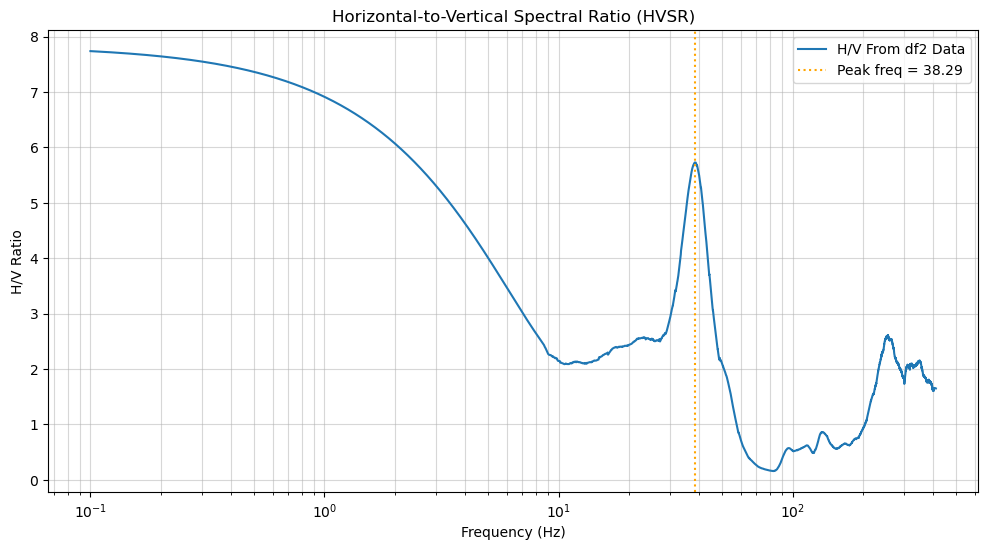

Full df3 data peak frequency: 28.56666666666667 Hz
Full df3 data peak H/V: 6.228337215216769


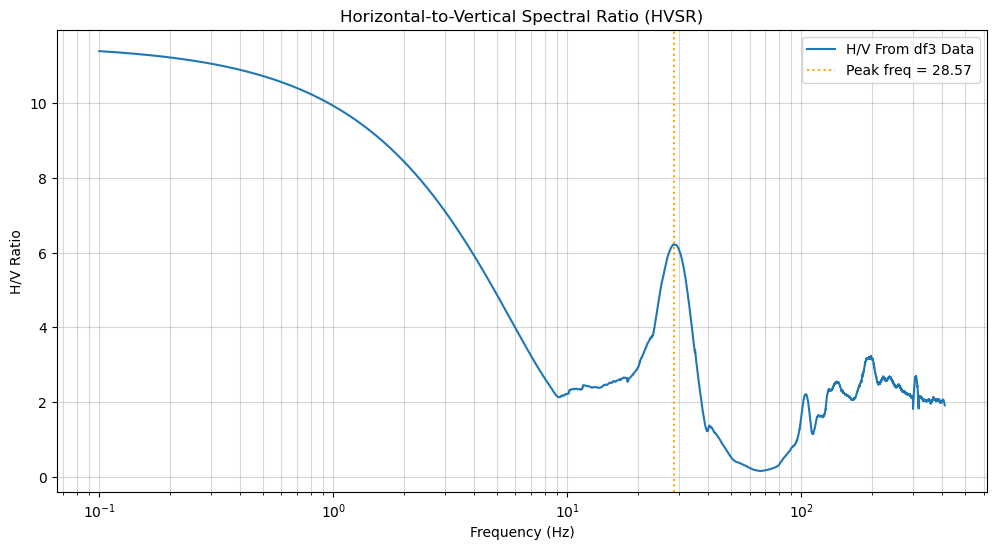

In [20]:
# With Option 1 (FFT-based):

# Get result for non-normalized df2 data:
freqs_df2, hvsr_df2 = H_V_ratio_fft(df2, 'NS_Detrended', df2, 'EW_Detrended', df2, 'Z_Detrended', original_sampling_rate)
# Apply smoothing with Savitzky-Golay filter
hvsr_df2_smooth = savgol_filter(hvsr_df2, window_length=20481, polyorder=2) # window_length should be an odd integer
hvsr_df2_smooth = savgol_filter(hvsr_df2_smooth, window_length=101, polyorder=2)# increase smoothing with multiple filter passes if needed
# Find main peak in given frequency range:
peak_idx_df2 = np.argmax(hvsr_df2_smooth[(freqs_df2 > 10) & (freqs_df2 < 50)])
peak_freq_df2 = freqs_df2[(freqs_df2 > 10) & (freqs_df2 < 50)][peak_idx_df2]
peak_value_df2 = hvsr_df2_smooth[(freqs_df2 > 10) & (freqs_df2 < 50)][peak_idx_df2]
print(f"Full df2 data peak frequency: {peak_freq_df2} Hz")
print(f"Full df2 data peak H/V: {peak_value_df2}")

# Plot:
plt.figure(figsize=(12, 6))
plt.semilogx(freqs_df2, hvsr_df2_smooth, label="H/V From df2 Data")
plt.xlabel('Frequency (Hz)')
plt.ylabel('H/V Ratio')
plt.title('Horizontal-to-Vertical Spectral Ratio (HVSR)')
plt.grid(True, which="both", alpha=0.5)
plt.axvline(x=peak_freq_df2, linestyle=":", color='orange', label=f'Peak freq = {peak_freq_df2:.2f}') 
plt.legend(loc='upper right')
plt.show()
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Get result for non-normalized df3 data:
freqs_df3, hvsr_df3 = H_V_ratio_fft(df3, 'NS_Detrended', df3, 'EW_Detrended', df3, 'Z_Detrended', original_sampling_rate)
# Apply smoothing with Savitzky-Golay filter
hvsr_df3_smooth = savgol_filter(hvsr_df3, window_length=20481, polyorder=2) # window_length should be an odd integer
hvsr_df3_smooth = savgol_filter(hvsr_df3_smooth, window_length=101, polyorder=2)
# Find main peak in given frequency range:
peak_idx_df3 = np.argmax(hvsr_df3_smooth[(freqs_df3 > 10) & (freqs_df3 < 50)])
peak_freq_df3 = freqs_df3[(freqs_df3 > 10) & (freqs_df3 < 50)][peak_idx_df3]
peak_value_df3 = hvsr_df3_smooth[(freqs_df3 > 10) & (freqs_df3 < 50)][peak_idx_df3]
print(f"Full df3 data peak frequency: {peak_freq_df3} Hz")
print(f"Full df3 data peak H/V: {peak_value_df3}")

# Plot:
plt.figure(figsize=(12, 6))
plt.semilogx(freqs_df3, hvsr_df3_smooth, label="H/V From df3 Data")
plt.xlabel('Frequency (Hz)')
plt.ylabel('H/V Ratio')
plt.title('Horizontal-to-Vertical Spectral Ratio (HVSR)')
plt.grid(True, which="both", alpha=0.5)
plt.axvline(x=peak_freq_df3, linestyle=":", color='orange', label=f'Peak freq = {peak_freq_df3:.2f}') 
plt.legend(loc='upper right')
plt.show()

##### Option 2 - Segmented FFT-based:

In [45]:
# Not sure about this method, didn't get very good curve for df data
# df2:
# freqs_segmented2, HV_segmented2, HV_std2 = H_V_ratio_fft_segmented(df2, 'NS_Detrended', df2, 'EW_Detrended', df2, 'Z_Detrended', original_sampling_rate,
#                                                                   segment_size=250, freq_max=100)
# # Try SG filter here too?
# #HV_segmented2_smooth = savgol_filter(HV_segmented2, window_length=5, polyorder=2) # window_length should be an odd integer
# # Find main peak:
# peak_idx_s2 = np.argmax(HV_segmented2[(freqs_segmented2 > 10) & (freqs_segmented2 < 50)])
# peak_freq_s2 = freqs_segmented2[(freqs_segmented2 > 10) & (freqs_segmented2 < 50)][peak_idx_s2]
# peak_value_s2 = HV_segmented2[(freqs_segmented2 > 10) & (freqs_segmented2 < 50)][peak_idx_s2]
# print(f"Full df2 data peak frequency: {peak_freq_s2} Hz")
# print(f"Full df2 data peak H/V: {peak_value_s2}")

# # Plot:
# plt.figure(figsize=(12, 6))
# plt.semilogx(freqs_segmented2, HV_segmented2, label="H/V From df Data")
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('H/V Ratio')
# plt.title('Horizontal-to-Vertical Spectral Ratio (HVSR)')
# plt.grid(True, which="both", alpha=0.5)
# plt.axvline(x=peak_freq_s2, linestyle=":", color='orange', label=f'Peak freq = {peak_freq_s2:.2f}') 
# plt.legend(loc='upper left')
# plt.show()
# #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# # df3:
# freqs_segmented3, HV_segmented3, HV_std3 = H_V_ratio_fft_segmented(df3, 'NS_Detrended', df3, 'EW_Detrended', df3, 'Z_Detrended', original_sampling_rate,
#                                                                   segment_size=250, freq_max=100)
# # Try SG filter here too?
# #HV_segmented3_smooth = savgol_filter(HV_segmented3, window_length=5, polyorder=2) # window_length should be an odd integer
# # Find main peak:
# peak_idx_s3 = np.argmax(HV_segmented3[(freqs_segmented3 > 10) & (freqs_segmented3 < 50)])
# peak_freq_s3 = freqs_segmented3[(freqs_segmented3 > 10) & (freqs_segmented3 < 50)][peak_idx_s3]
# peak_value_s3 = HV_segmented3[(freqs_segmented3 > 10) & (freqs_segmented3 < 50)][peak_idx_s3]
# print(f"Full df3 data peak frequency: {peak_freq_s3} Hz")
# print(f"Full df3 data peak H/V: {peak_value_s3}")

# # Plot:
# plt.figure(figsize=(12, 6))
# plt.semilogx(freqs_segmented3, HV_segmented3, label="H/V From df Data")
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('H/V Ratio')
# plt.title('Horizontal-to-Vertical Spectral Ratio (HVSR)')
# plt.grid(True, which="both", alpha=0.5)
# plt.axvline(x=peak_freq_s3, linestyle=":", color='orange', label=f'Peak freq = {peak_freq_s3:.2f}') 
# plt.legend(loc='upper left')
# plt.show()

##### Option 3 - PSD-based:

Full df2 data peak frequency: 38.912 Hz
Full df2 data peak H/V: 3.4505371532402727


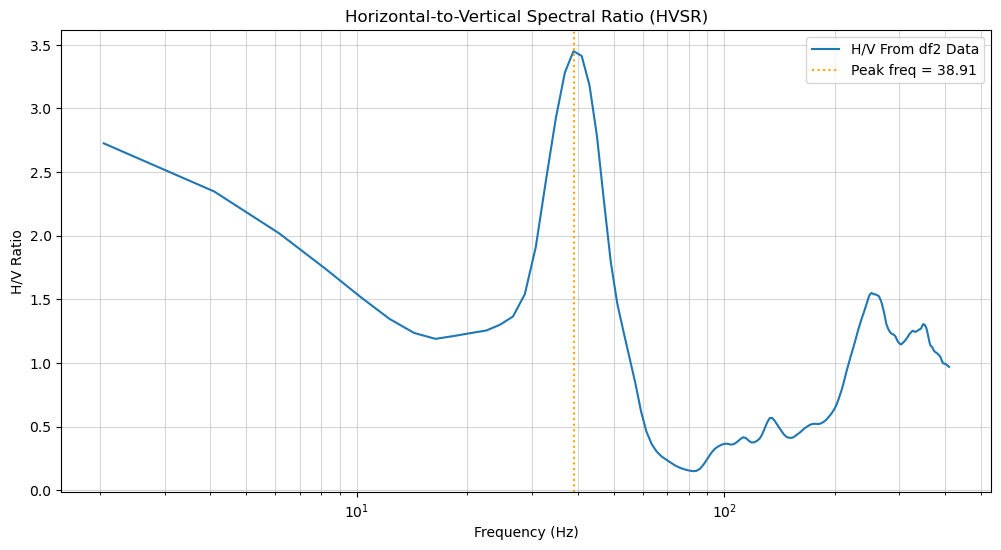

Full df3 data peak frequency: 28.672 Hz
Full df3 data peak H/V: 2.488764859689396


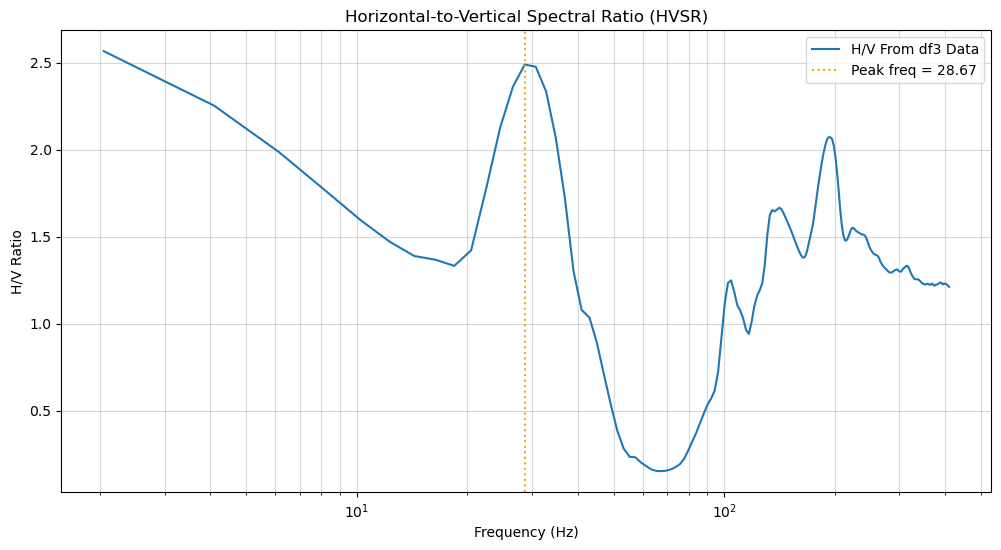

In [24]:
# With Option 3 (PSD-based):

freqs2_psd, hvsr2_psd, _, _, _ = H_V_ratio_psd(df2, 'NS_Detrended', df2, 'EW_Detrended', df2, 'Z_Detrended', original_sampling_rate, segment_size=500)
# Try SG filter here too?
hvsr2_psd_smooth = savgol_filter(hvsr2_psd, window_length=11, polyorder=2) # window_length should be an odd integer
# Find main peak:
peak_idx_psd2 = np.argmax(hvsr2_psd_smooth[(freqs2_psd > 10) & (freqs2_psd < 50)])
peak_freq_psd2 = freqs1_psd[(freqs2_psd > 10) & (freqs2_psd < 50)][peak_idx_psd2]
peak_value_psd2 = hvsr2_psd_smooth[(freqs2_psd > 10) & (freqs2_psd < 50)][peak_idx_psd2]
print(f"Full df2 data peak frequency: {peak_freq_psd2} Hz")
print(f"Full df2 data peak H/V: {peak_value_psd2}")

# Plot:
plt.figure(figsize=(12, 6))
plt.semilogx(freqs2_psd, hvsr2_psd_smooth, label="H/V From df2 Data")
plt.xlabel('Frequency (Hz)')
plt.ylabel('H/V Ratio')
plt.title('Horizontal-to-Vertical Spectral Ratio (HVSR)')
plt.grid(True, which="both", alpha=0.5)
plt.axvline(x=peak_freq_psd2, linestyle=":", color='orange', label=f'Peak freq = {peak_freq_psd2:.2f}') 
plt.legend(loc='upper right')
plt.show()
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
freqs3_psd, hvsr3_psd, _, _, _ = H_V_ratio_psd(df3, 'NS_Detrended', df3, 'EW_Detrended', df3, 'Z_Detrended', original_sampling_rate, segment_size=500)
# Try SG filter here too?
hvsr3_psd_smooth = savgol_filter(hvsr3_psd, window_length=11, polyorder=2) # window_length should be an odd integer
# Find main peak:
peak_idx_psd3 = np.argmax(hvsr3_psd_smooth[(freqs3_psd > 10) & (freqs3_psd < 50)])
peak_freq_psd3 = freqs3_psd[(freqs3_psd > 10) & (freqs3_psd < 50)][peak_idx_psd3]
peak_value_psd3 = hvsr3_psd_smooth[(freqs3_psd > 10) & (freqs3_psd < 50)][peak_idx_psd3]
print(f"Full df3 data peak frequency: {peak_freq_psd3} Hz")
print(f"Full df3 data peak H/V: {peak_value_psd3}")

# Plot:
plt.figure(figsize=(12, 6))
plt.semilogx(freqs3_psd, hvsr3_psd_smooth, label="H/V From df3 Data")
plt.xlabel('Frequency (Hz)')
plt.ylabel('H/V Ratio')
plt.title('Horizontal-to-Vertical Spectral Ratio (HVSR)')
plt.grid(True, which="both", alpha=0.5)
plt.axvline(x=peak_freq_psd3, linestyle=":", color='orange', label=f'Peak freq = {peak_freq_psd3:.2f}') 
plt.legend(loc='upper right')
plt.show()

##### Comparison Plots:

DataFrame: df2


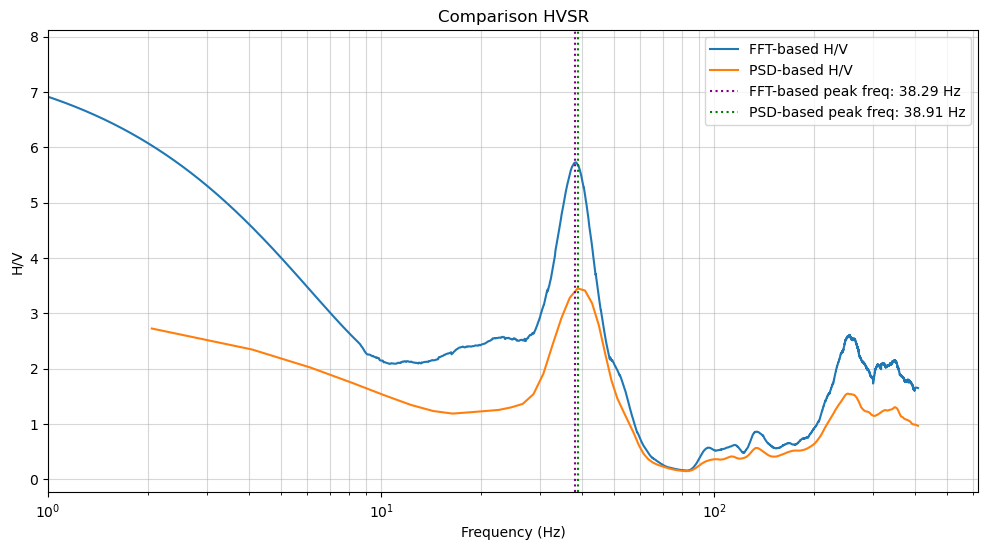

DataFrame: df3


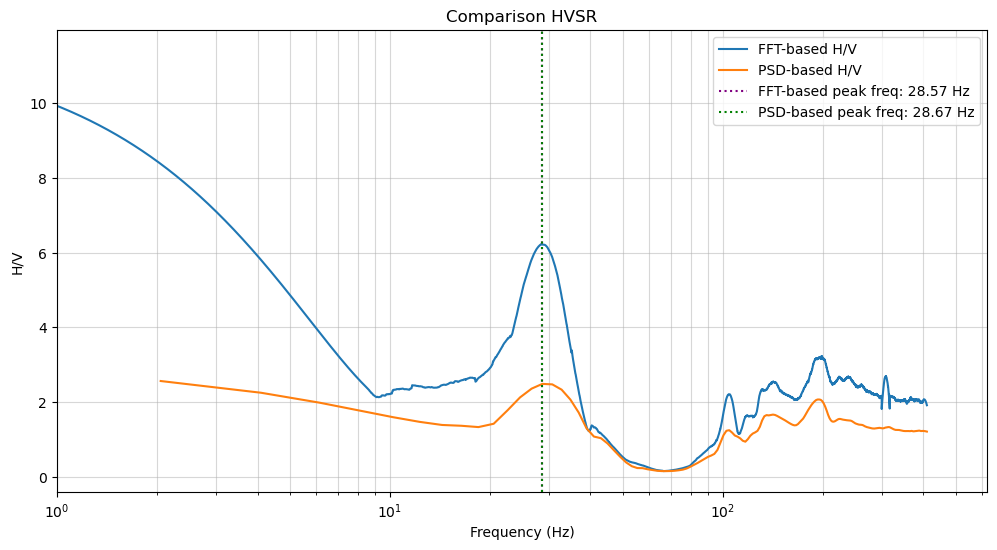

In [26]:
#df2 HVSR Comparison Plot:
print("DataFrame: df2")
fig1, ax1 = plt.subplots(figsize=(12,6))
ax1.semilogx(freqs_df2, hvsr_df2_smooth, label="FFT-based H/V")
ax1.semilogx(freqs2_psd, hvsr2_psd_smooth, label="PSD-based H/V")
ax1.axvline(x=peak_freq_df2, linestyle=":", color='purple', label=f'FFT-based peak freq: {peak_freq_df2:.2f} Hz') 
ax1.axvline(x=peak_freq_psd2, linestyle=":", color='green', label=f'PSD-based peak freq: {peak_freq_psd2:.2f} Hz') 
ax1.set_ylabel("H/V")
ax1.set_xlabel("Frequency (Hz)")
ax1.legend(loc='upper right')
ax1.set_title("Comparison HVSR")
ax1.set_xlim(left=1)
plt.grid(True, which='both', alpha=0.5)
plt.show()

# df3 HVSR Comparison Plot:
print("DataFrame: df3")
fig2, ax2 = plt.subplots(figsize=(12,6))
ax2.semilogx(freqs_df3, hvsr_df3_smooth, label="FFT-based H/V")
ax2.semilogx(freqs3_psd, hvsr3_psd_smooth, label="PSD-based H/V")
ax2.axvline(x=peak_freq_df3, linestyle=":", color='purple', label=f'FFT-based peak freq: {peak_freq_df3:.2f} Hz') 
ax2.axvline(x=peak_freq_psd3, linestyle=":", color='green', label=f'PSD-based peak freq: {peak_freq_psd3:.2f} Hz') 
ax2.set_ylabel("H/V")
ax2.set_xlabel("Frequency (Hz)")
ax2.legend(loc='upper right')
ax2.set_title("Comparison HVSR")
ax2.set_xlim(left=1)
plt.grid(True, which='both', alpha=0.5)
plt.show()